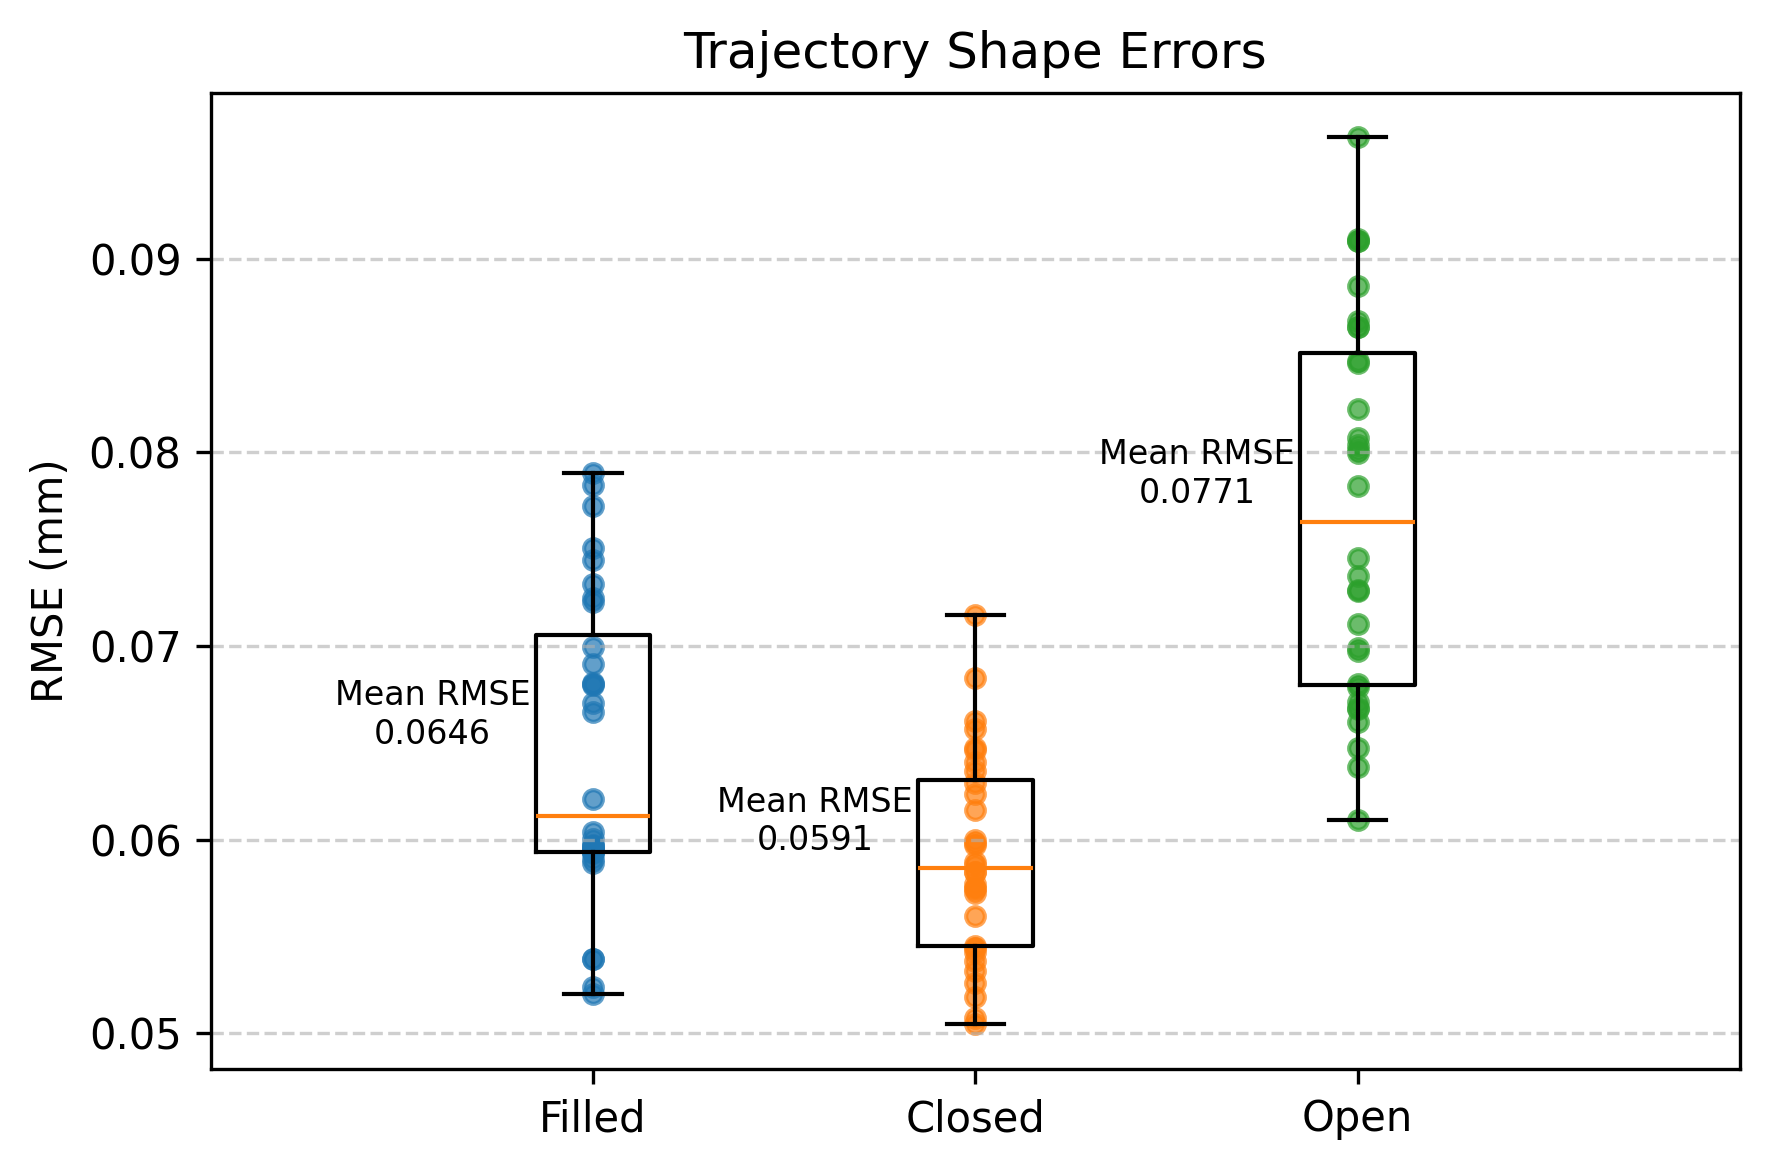

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("traj_data.csv")

data = [df["filled"], df["closed"], df["open"]]
labels = ["Filled", "Closed", "Open"]

plt.figure(figsize=(6, 4), dpi=300)

# Boxplot
plt.boxplot(
    data,
    labels=labels,
    showmeans=False
)

plt.xlim(0, 4)

# Overlay individual points (with slight jitter)
for i, y in enumerate(data, start=1):
    x = np.full(len(y), i)
    plt.scatter(x, y, alpha=0.7, s=20)

# Compute and plot means
means = [np.mean(y) for y in data]

for i, mean in enumerate(means, start=1):
    # plt.scatter(i, mean, marker='D', s=60)  # diamond marker for mean
    plt.text(i-.42, mean, f"Mean RMSE\n{mean:.4f}", 
             ha='center', va='bottom', fontsize=8)

# Labels
plt.ylabel("RMSE (mm)")
plt.title("Trajectory Shape Errors")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Trajectory Mode Error.png", dpi=300)
plt.show()